In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

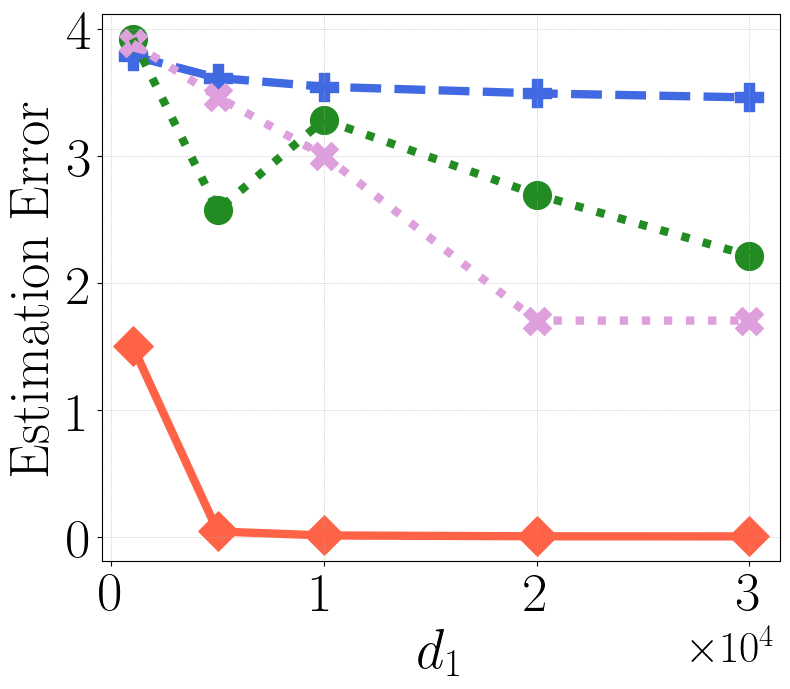

In [18]:
d1 = [1000, 2000, 5000, 10000, 20000, 30000]
alt_GD = np.array([528.3113342, 272.4608154, 55.2882874, 21.4115620, 12.6143820, 10.7649256])
softimpute_als = np.array([3.7888470, 3.7273029, 3.6143648, 3.5455268, 3.4931482, 3.4613315])
nuclear_reg = np.array([3.9230829, 3.8435083, 2.5751333, 3.2846257, 2.6972797, 2.2170639])
iipw_1 = np.array([3.8866611, 3.7748066, 3.4643601, 3.0032921, 1.7050502, 1.7050502])
iipw = np.array([1.5034147, 0.3564337, 0.0456746, 0.0146587, 0.0079182, 0.0071486])

variables = ['d1', 'alt_GD', 'softimpute_als', 'nuclear_reg','iipw_1', 'iipw']
for var in variables:
    #globals()[var] = globals()[var][1:]
    globals()[var] = np.delete(globals()[var], 1)

f, ax = plt.subplots(figsize=(8,7))

#plt.plot(d1, alt_GD, lw=4, color='royalblue',ls="dotted" )
plt.plot(d1, softimpute_als, lw=6, color='royalblue', ls="dashed")
plt.plot(d1, nuclear_reg, lw=6, color='forestgreen', ls="dotted")
plt.plot(d1, iipw_1, lw=6, color='plum', ls="dotted")
plt.plot(d1, iipw, color='tomato',lw=6)

#plt.scatter(d1, alt_GD, s=400, color='royalblue', label=r"$\mathrm{Alt.~GD}$", marker="X")
plt.scatter(d1, softimpute_als, s=400, color='royalblue', label=r"$\mathrm{SoftImpute}$"+"\n"+r"$\mathrm{ALS}$", marker="P")
plt.scatter(d1, nuclear_reg, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
plt.scatter(d1, iipw_1, s=400, color='plum', label=r"$\mathrm{Alg.~1~(1~step)}$", marker="X")
plt.scatter(d1, iipw, s=400, color='tomato', label=r"$\mathrm{Alg.~1}$", marker="D")


plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{Estimation~Error}$", fontsize=40)
plt.yticks([0,1,2,3,4], fontsize=40)

xticks = [0].extend(d1)
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

plt.yticks(fontsize=40)
#plt.yscale('log')
ax.set_xticks([0, 10000, 20000, 30000])
ax.xaxis.get_offset_text().set_fontsize(32)

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"five_entries_per_row_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

[0.01822   0.0116478 0.0103066 0.0094056 0.0093011]


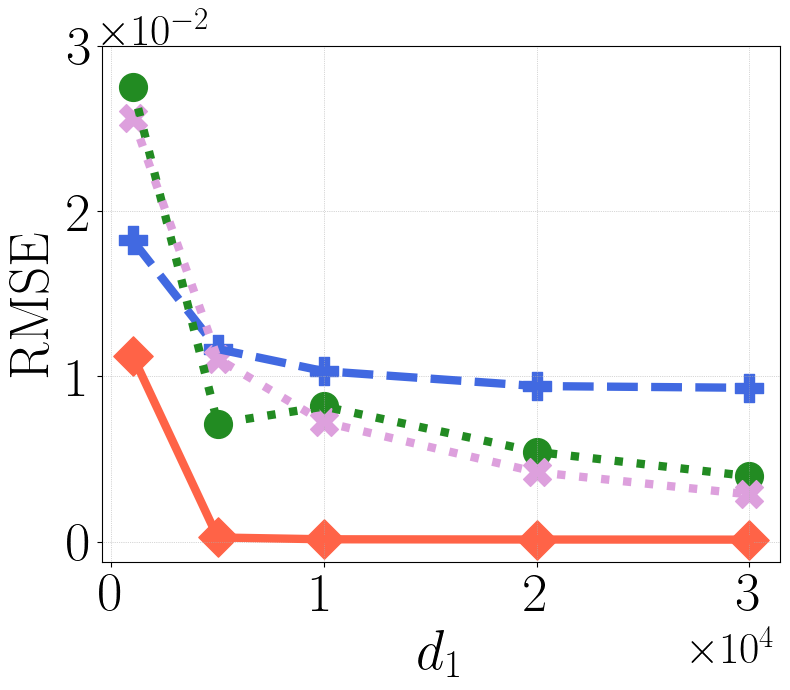

In [19]:
d1 = [1000, 2000, 5000, 10000, 20000, 30000]

alt_GD_rmse = np.array([0.0636601, 0.0636410, 0.0636911, 0.0636531, 0.0635144, 0.0632027])
softimpute_als_rmse = np.array([0.0182200, 0.0147932, 0.0116478, 0.0103066, 0.0094056, 0.0093011])
nuclear_reg_rmse = np.array([0.0275115, 0.0193523, 0.0071384, 0.0081713, 0.0054233, 0.0039521])
iipw_1_rmse = np.array([0.0256448, 0.0181943, 0.0110687, 0.0072250, 0.0041964, 0.0028500])
iipw_rmse = np.array([0.0112377, 0.0026970, 0.0002450, 0.0001350, 0.0001205, 0.0001136])

variables = ['d1', 'alt_GD_rmse', 'softimpute_als_rmse', 'nuclear_reg_rmse','iipw_1_rmse', 'iipw_rmse']
for var in variables:
    #globals()[var] = globals()[var][1:]
    globals()[var] = np.delete(globals()[var], 1)

f, ax = plt.subplots(figsize=(8,7))
print(softimpute_als_rmse)
#plt.plot(d1, alt_GD_rmse, lw=4, color='royalblue',ls="dotted" )
plt.plot(d1, softimpute_als_rmse, lw=6, color='royalblue', ls="dashed")
plt.plot(d1, nuclear_reg_rmse, lw=6, color='forestgreen', ls="dotted")
plt.plot(d1, iipw_1_rmse, lw=6, color='plum', ls="dotted")
plt.plot(d1, iipw_rmse, color='tomato',lw=6)

#plt.scatter(d1, alt_GD_rmse, s=400, color='royalblue', label=r"$\widehat{T}$", marker="X")
plt.scatter(d1, softimpute_als_rmse, s=400, color='royalblue', label=r"$\mathrm{SoftImpute}$"+"\n"+r"$\mathrm{ALS}$", marker="P")
plt.scatter(d1, nuclear_reg_rmse, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
plt.scatter(d1, iipw_1_rmse, s=400, color='plum', label=r"$\mathrm{Alg.~1~(1~step)}$", marker="X")
plt.scatter(d1, iipw_rmse, s=400, color='tomato', label=r"$\mathrm{Alg.~1}$", marker="D")

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

xticks = [0].extend(d1)
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
ax.set_xticks([0, 10000, 20000, 30000])
ax.xaxis.get_offset_text().set_fontsize(32)


plt.yticks(fontsize=40)
#plt.yscale('log')
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='y')
ax.set_yticks([0,1e-2, 2e-2, 3e-2])
ax.yaxis.get_offset_text().set_fontsize(32)

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"five_entries_per_row_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()